# User Retention and Churn Analysis
## Notebook 1: Data Exploration

**Author:** Vijayalakshmi Veeraiyan  


---

## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
plt.style.use('seaborn-v0_8')

print('Libraries loaded successfully!')

Libraries loaded successfully!


## About This Project

**Project:** User Retention & Churn Analysis  
**Dataset:** IBM Telecom Customer Churn (Kaggle)  
**Goal:** Predict which customers are likely to
leave so the business can intervene early with
targeted retention strategies.

### The Business Problem

Customer churn — when a customer stops using
a service. It is one of the most costly problems
in any subscription-based business. Acquiring
a new customer typically costs 5-7x more than
retaining an existing one.

If we can identify which customers are at risk
of leaving *before* they actually leave, the
business can offer targeted incentives,
improve service, or address specific pain
points in saving significant revenue.

### The Data Science Approach

This project follows a complete end-to-end
machine learning pipeline:

1. **Notebook 1** — Explore the data and
   understand key patterns
2. **Notebook 2** — Clean, engineer features,
   and prepare data for modeling
3. **Notebook 3** — Build, tune and evaluate
   ML models and calculate business impact

### Key Business Assumptions
- Monthly revenue per customer: $70

- Average customer lifetime: 24 months
- Customer Lifetime Value (CLV): $1,680

- Retention offer cost: $50 per customer

## 2. Load the Dataset

Upload `telecom_customer_churn.csv` to your Google Colab session before running this cell.

In [ ]:
# Load the dataset
file_path = '/content/telecom_customer_churn.csv'
df = pd.read_csv(file_path)

print(f'Dataset loaded successfully!')
print(f'Shape: {df.shape[0]} rows x {df.shape[1]} columns')

Dataset loaded successfully!
Shape: 7043 rows x 38 columns


## Understanding the Dataset

The dataset contains **7,043 telecom customers**
with **38 features** covering five main areas:

### 1. Customer Demographics
- Age, gender, marital status
- Number of dependents
- Location (city, zip code)

### 2. Service Usage
- Phone service, internet type
- Streaming TV, movies, music
- Online security, backup, device protection

### 3. Contract & Billing
- Contract type (Month-to-Month, 1-year, 2-year)
- Payment method, paperless billing
- Monthly charge, total charges

### 4. Engagement Signals
- Number of referrals made
- Tenure in months
- Number of dependents

### 5. Churn Information (Target Variable)
- Customer Status — Stayed, Churned, or Joined
- Churn Category — reason for leaving
- Churn Reason — specific reason

### What We Are Predicting
We want to predict **Customer Status = Churned**
for each customer — converting this into a
binary classification problem:
- **1** = Customer Churned
- **0** = Customer Stayed or Joined

## 3. Basic Dataset Overview

In [ ]:
# First 5 rows
print('First 5 rows of the dataset:')
df.head()

First 5 rows of the dataset:


,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,Internet Type,Avg Monthly GB Download,Online Security,Online Backup,Device Protection Plan,Premium Tech Support,Streaming TV,Streaming Movies,Streaming Music,Unlimited Data,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,9,NaN,Yes,42.39,No,Yes,Cable,16.0,No,Yes,No,Yes,Yes,No,No,Yes,One Year,Yes,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,9,NaN,Yes,10.69,Yes,Yes,Cable,10.0,No,No,No,No,No,Yes,Yes,No,Month-to-Month,No,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,4,Offer E,Yes,33.65,No,Yes,Fiber Optic,30.0,No,No,Yes,No,No,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,13,Offer D,Yes,27.82,No,Yes,Fiber Optic,4.0,No,Yes,Yes,No,Yes,Yes,No,Yes,Month-to-Month,Yes,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,3,NaN,Yes,7.38,No,Yes,Fiber Optic,11.0,No,No,No,Yes,Yes,No,No,Yes,Month-to-Month,Yes,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability


In [ ]:
# Data types
print('Column data types:')
print(df.dtypes)

Column data types:
Customer ID                           object
Gender                                object
Age                                    int64
Married                               object
Number of Dependents                   int64
City                                  object
Zip Code                               int64
Latitude                             float64
Longitude                            float64
Number of Referrals                    int64
Tenure in Months                       int64
Offer                                 object
Phone Service                         object
Avg Monthly Long Distance Charges    float64
Multiple Lines                        object
Internet Service                      object
Internet Type                         object
Avg Monthly GB Download              float64
Online Security                       object
Online Backup                         object
Device Protection Plan                object
Premium Tech Support                

In [ ]:
# Basic statistics for numerical columns
print('Summary statistics:')
df.describe()

Summary statistics:


,Age,Number of Dependents,Zip Code,Latitude,Longitude,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,6361.000000,5517.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,46.509726,0.468692,93486.070567,36.197455,-119.756684,1.951867,32.386767,25.420517,26.189958,63.596131,2280.381264,1.962182,6.860713,749.099262,3034.379056
std,16.750352,0.962802,1856.767505,2.468929,2.154425,3.001199,24.542061,14.200374,19.586585,31.204743,2266.220462,7.902614,25.104978,846.660055,2865.204542
min,19.000000,0.000000,90001.000000,32.555828,-124.301372,0.000000,1.000000,1.010000,2.000000,-10.000000,18.800000,0.000000,0.000000,0.000000,21.360000
25%,32.000000,0.000000,92101.000000,33.990646,-121.788090,0.000000,9.000000,13.050000,13.000000,30.400000,400.150000,0.000000,0.000000,70.545000,605.610000
50%,46.000000,0.000000,93518.000000,36.205465,-119.595293,0.000000,29.000000,25.690000,21.000000,70.050000,1394.550000,0.000000,0.000000,401.440000,2108.640000
75%,60.000000,0.000000,95329.000000,38.161321,-117.969795,3.000000,55.000000,37.680000,30.000000,89.750000,3786.600000,0.000000,0.000000,1191.100000,4801.145000
max,80.000000,9.000000,96150.000000,41.962127,-114.192901,11.000000,72.000000,49.990000,85.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000


## 4. Missing Values Analysis

In [ ]:
# Count missing values per column
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})

# Show only columns with missing values
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
print('Columns with missing values:')
print(missing_df)

Columns with missing values:
                                   Missing Count  Missing %
Churn Category                              5174      73.46
Churn Reason                                5174      73.46
Offer                                       3877      55.05
Online Security                             1526      21.67
Online Backup                               1526      21.67
Avg Monthly GB Download                     1526      21.67
Internet Type                               1526      21.67
Streaming Movies                            1526      21.67
Streaming TV                                1526      21.67
Device Protection Plan                      1526      21.67
Premium Tech Support                        1526      21.67
Unlimited Data                              1526      21.67
Streaming Music                             1526      21.67
Avg Monthly Long Distance Charges            682       9.68
Multiple Lines                               682       9.68


## Understanding Missing Values

Not all missing values mean the same thing.
Before deciding how to handle them, we need
to understand **why** they are missing.

### Missing Value Analysis

| Column | Missing | Why |
|---|---|---|
| Offer | 3,877 (55%) | Customer never received an offer |
| Internet Type | 1,526 (22%) | Customer has no internet service |
| Avg Monthly GB | 1,526 (22%) | No internet = no data usage |
| Online Security | 1,526 (22%) | No internet = no online services |
| Churn Category | 5,174 (73%) | Customer did not churn |
| Churn Reason | 5,174 (73%) | Customer did not churn |

### Key Insight — Missing ≠ Unknown

The 5,174 missing values in Churn Category
and Churn Reason are **not unknown data** —
they are missing because those customers
simply did not churn. There is no churn
reason to record.

We will fill these with **"No Churn"** —
a meaningful category, not a guess.

Similarly, the 1,526 missing internet-related
values belong to customers with no internet
service — the missing values are logically
correct and will be handled by our
preprocessing pipeline in Notebook 2.

### Why This Matters

Blindly dropping rows with missing values
would remove 73% of our dataset — destroying
valuable information. Understanding the
reason behind missing values allows us to
handle them intelligently rather than
losing data unnecessarily.

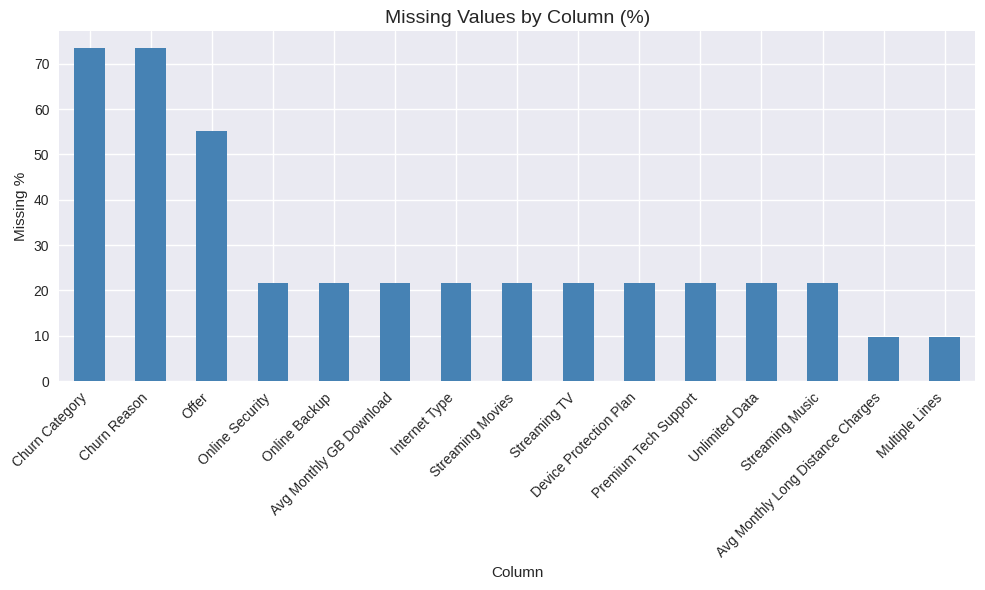

Chart saved as missing_values.png


In [ ]:
# Visualise missing values
plt.figure(figsize=(10, 6))
missing_df['Missing %'].plot(kind='bar', color='steelblue')
plt.title('Missing Values by Column (%)', fontsize=14)
plt.xlabel('Column')
plt.ylabel('Missing %')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('missing_values.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved as missing_values.png')

## 5. Target Variable Analysis — Churn Distribution

Customer Status Distribution:
  Stayed: 4720 customers (67.0%)
  Churned: 1869 customers (26.5%)
  Joined: 454 customers (6.4%)


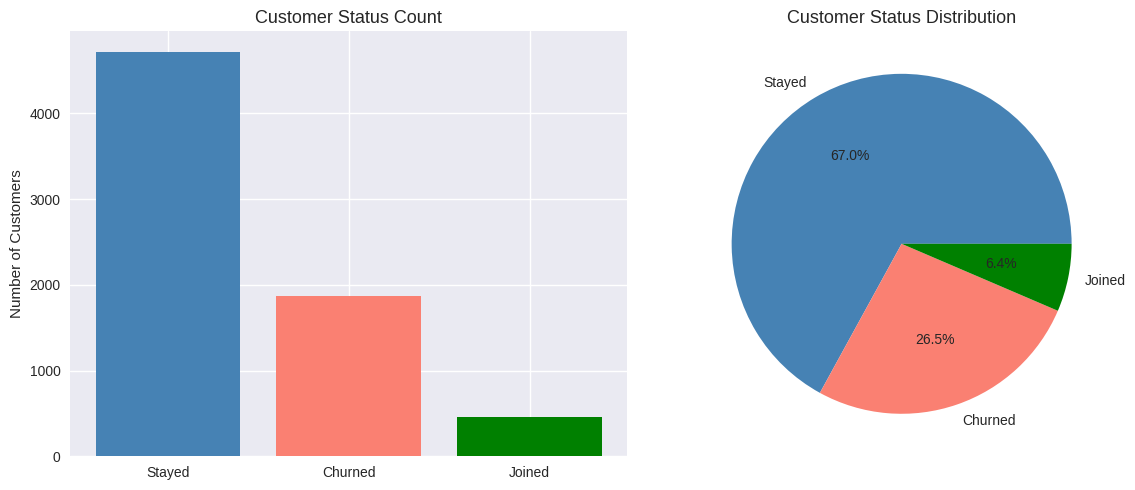


Note: Class imbalance exists — churned customers are minority class


In [ ]:
# Churn distribution
churn_counts = df['Customer Status'].value_counts()
churn_pct = df['Customer Status'].value_counts(normalize=True) * 100

print('Customer Status Distribution:')
for status in churn_counts.index:
    print(f'  {status}: {churn_counts[status]} customers ({churn_pct[status]:.1f}%)')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
axes[0].bar(churn_counts.index, churn_counts.values, color=['steelblue', 'salmon', 'green'])
axes[0].set_title('Customer Status Count', fontsize=13)
axes[0].set_ylabel('Number of Customers')

# Pie chart
axes[1].pie(churn_counts.values, labels=churn_counts.index, autopct='%1.1f%%',
            colors=['steelblue', 'salmon', 'green'])
axes[1].set_title('Customer Status Distribution', fontsize=13)

plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nNote: Class imbalance exists — churned customers are minority class')

## The Class Imbalance Problem

### What We See
- **Stayed:** ~73.5% of customers
- **Churned:** ~26.5% of customers

This is called **class imbalance** — where
one outcome is significantly more common
than the other.

### Why This is a Serious Problem

Imagine we built a model that simply
predicted "every customer stays" for
every single prediction — without looking
at any features at all.

That model would be:
- **73.5% accurate** ✅ looks impressive
- **0% useful** ❌ catches zero churners

This is called the **Accuracy Trap** —
a model can score high on accuracy while
completely failing at its actual purpose.

### A Real World Analogy

Think of a spam filter that marks every
email as "not spam." It would be nearly
100% accurate — because most emails
genuinely are not spam. But it would
be completely useless because it never
catches any spam at all.

### How We Fix This

In Notebook 2 we use **SMOTE**
(Synthetic Minority Oversampling Technique)
to balance the training data.

SMOTE creates synthetic examples of the
minority class (churners) by interpolating
between existing churner records — giving
the model equal exposure to both classes
during training.

**Important:** SMOTE is applied only to
training data — never test data. The test
set must reflect real world distribution
to give honest evaluation results.

### Why This Matters for Business

A model that catches no churners provides
zero business value regardless of its
accuracy score. The goal is not a model
that scores well on paper but one that
actually helps the business retain
customers and protect revenue.

## 6. Key Feature Exploration

Churn Rate by Contract Type:
Contract
Month-to-Month    45.8
One Year          10.7
Two Year           2.5
Name: Churned, dtype: float64


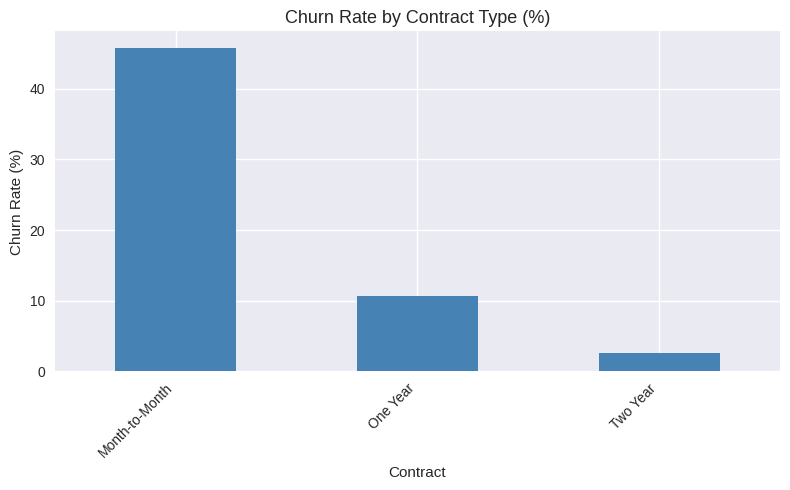

In [ ]:
# Create binary churn flag for analysis
df['Churned'] = (df['Customer Status'] == 'Churned').astype(int)

# Churn rate by Contract type
contract_churn = df.groupby('Contract')['Churned'].mean() * 100
print('Churn Rate by Contract Type:')
print(contract_churn.round(1))

plt.figure(figsize=(8, 5))
contract_churn.plot(kind='bar', color='steelblue')
plt.title('Churn Rate by Contract Type (%)', fontsize=13)
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('churn_by_contract.png', dpi=150, bbox_inches='tight')
plt.show()

## Key Finding 1 — Contract Type is the
Strongest Churn Predictor

### What the Data Shows

The churn rate varies dramatically by
contract type:

| Contract Type | Churn Rate |
|---|---|
| Month-to-Month | ~47% |
| One Year | ~11% |
| Two Year | ~3% |

Month-to-Month customers churn at
**nearly 16x the rate** of Two Year
contract customers.

### Why This Makes Business Sense

Month-to-Month customers have:
- **No financial penalty** for leaving
- **No commitment** to the service
- **Full flexibility** to switch anytime

They can respond immediately to
competitor offers, price changes
or service dissatisfaction with
zero switching cost.

Two Year contract customers, by
contrast, have made a deliberate
long-term commitment. They have
already evaluated alternatives
and chosen to stay.

### Why This Becomes Our Most
Important Feature

This observation is later confirmed
by our Gradient Boosting model.
Month-to-Month contract is the
single strongest predictor with a
feature importance score of **0.384**.

That is nearly **4x higher** than
the second most important feature.

### Business Recommendation

Prioritise converting Month-to-Month
customers to longer contracts by
offering meaningful incentives —
discounts, loyalty rewards or
additional services.

Even moving a customer from
Month-to-Month to a One Year contract
reduces their churn probability by
approximately 36 percentage points.

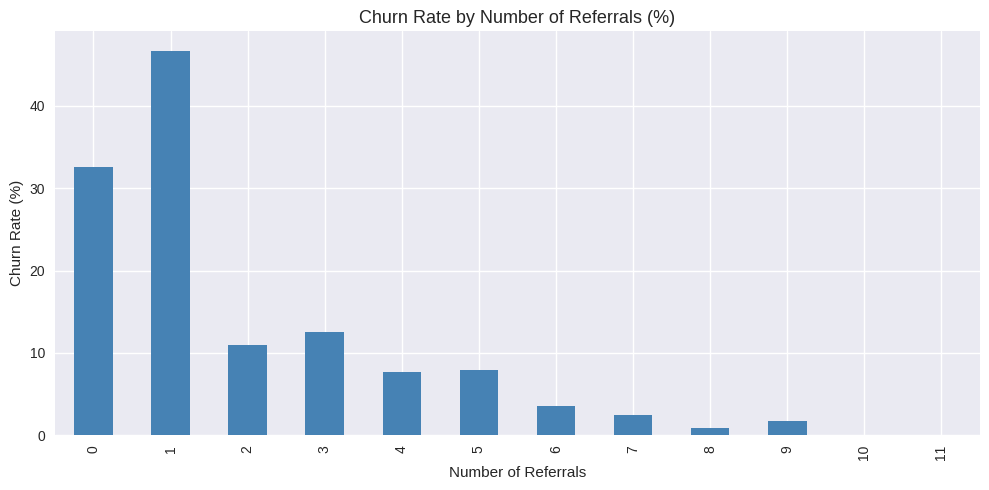

Observation: More referrals = lower churn rate (strong loyalty signal)


In [ ]:
# Churn rate by Number of Referrals
referral_churn = df.groupby('Number of Referrals')['Churned'].mean() * 100

plt.figure(figsize=(10, 5))
referral_churn.plot(kind='bar', color='steelblue')
plt.title('Churn Rate by Number of Referrals (%)', fontsize=13)
plt.ylabel('Churn Rate (%)')
plt.xlabel('Number of Referrals')
plt.tight_layout()
plt.savefig('churn_by_referrals.png', dpi=150, bbox_inches='tight')
plt.show()
print('Observation: More referrals = lower churn rate (strong loyalty signal)')

## Key Finding 2 — Referrals Signal Loyalty

### What the Data Shows

There is a clear and consistent pattern:

**More referrals = significantly lower
churn rate**

Customers with zero referrals have the
highest churn rate. As the number of
referrals increases, churn rate drops
dramatically.

### Why This Makes Business Sense

A customer who refers friends and family
to a service is:

**1. Publicly endorsing the brand**
They have told people they trust to
use this service. Their personal
reputation is now connected to the
product. Leaving would mean admitting
their recommendation was wrong.

**2. Socially invested**
Their friends and family are now also
customers. Leaving could create
awkward social situations — especially
if they encouraged others to sign up.

**3. Genuinely satisfied**
You rarely refer a service you are
unhappy with. Referrals are a strong
signal of real satisfaction — not
just passive acceptance.

### Why This Becomes an Important Feature

Our model confirms this observation —
Number of Referrals is the **second
strongest churn predictor** with a
feature importance score of **0.108**.

### Business Recommendation

Build and invest in a strong referral
programme. Every customer who refers
someone becomes significantly more
loyal themselves by creating a
dual benefit:

→ New customer acquired at low cost

→ Existing customer becomes more
  likely to stay long term

This is one of the highest ROI
retention strategies available. It simultaneously grows the customer
base and reduces churn.

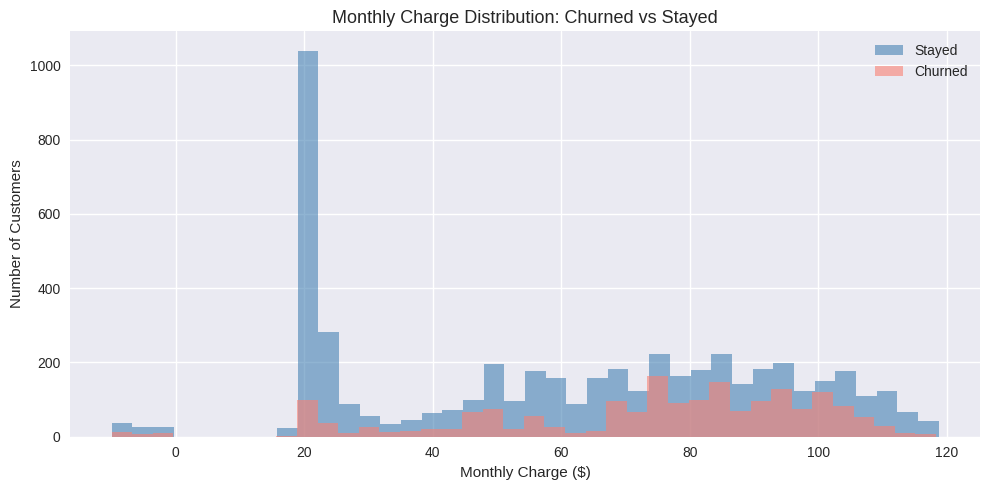

Average monthly charge - Churned: $73.35
Average monthly charge - Stayed: $60.07


In [ ]:
# Distribution of Monthly Charge for churned vs non-churned customers
churned = df[df['Churned'] == 1]['Monthly Charge']
stayed = df[df['Churned'] == 0]['Monthly Charge']

plt.figure(figsize=(10, 5))
plt.hist(stayed, bins=40, alpha=0.6, label='Stayed', color='steelblue')
plt.hist(churned, bins=40, alpha=0.6, label='Churned', color='salmon')
plt.title('Monthly Charge Distribution: Churned vs Stayed', fontsize=13)
plt.xlabel('Monthly Charge ($)')
plt.ylabel('Number of Customers')
plt.legend()
plt.tight_layout()
plt.savefig('monthly_charge_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Average monthly charge - Churned: ${churned.mean():.2f}')
print(f'Average monthly charge - Stayed: ${stayed.mean():.2f}')

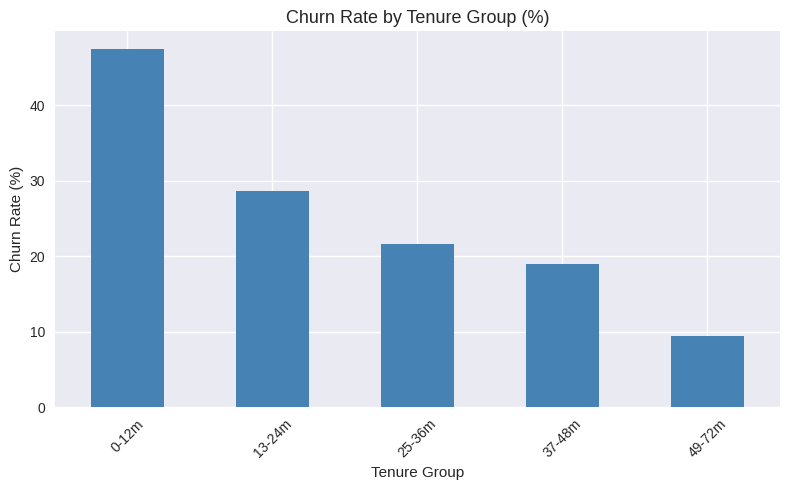

Observation: Newer customers churn more — early retention is critical


In [ ]:
# Churn rate by Tenure group
df['Tenure_Group'] = pd.cut(df['Tenure in Months'],
                             bins=[0, 12, 24, 36, 48, 72],
                             labels=['0-12m', '13-24m', '25-36m', '37-48m', '49-72m'])

tenure_churn = df.groupby('Tenure_Group', observed=True)['Churned'].mean() * 100

plt.figure(figsize=(8, 5))
tenure_churn.plot(kind='bar', color='steelblue')
plt.title('Churn Rate by Tenure Group (%)', fontsize=13)
plt.ylabel('Churn Rate (%)')
plt.xlabel('Tenure Group')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('churn_by_tenure.png', dpi=150, bbox_inches='tight')
plt.show()
print('Observation: Newer customers churn more — early retention is critical')

## Key Finding 3 — Early Tenure is the
Most Critical Retention Period

### What the Data Shows

Churn rate is highest in the first
12 months and drops significantly
as tenure increases.

| Tenure Group | Churn Risk |
|---|---|
| 0-12 months | Highest |
| 13-24 months | High |
| 25-36 months | Medium |
| 37-48 months | Low |
| 49-72 months | Lowest |

### Why This Makes Business Sense

New customers are in an evaluation phase.

They are still deciding whether the
service delivers on its promise. They
are comparing their experience against
competitor alternatives. They have not
yet built habits or dependency around
the service.

Long-term customers, by contrast, have:
- Integrated the service into their
  daily routine
- Already evaluated and rejected
  alternatives multiple times
- Built a relationship with the brand
- Accumulated loyalty benefits
  and history

### The Customer Lifecycle View

Think of customer retention like a
funnel with a leak at the top:

**Month 1-12:** Highest risk - customer
is still deciding if this was the
right choice

**Month 13-24:** Risk reduces as habits
form and switching costs increase

**Month 25+:** Customer is embedded -
churn becomes increasingly unlikely
with each passing month

### Business Recommendation

Invest heavily in the **first 90 days**
of a customer's journey — this is the
highest leverage period for retention.

Strategies that work:

→ Onboarding programmes that help
  customers get value quickly

→ Early check-in calls or messages

→ Special offers for customers
  approaching the 6-month mark

→ Proactive service quality monitoring
  for new customers

The goal is to get every customer
through the critical early period
and into the loyal long-term group.

### Connection to Monthly Spend Ratio

This finding directly motivates our
engineered feature

 **Monthly Spend Ratio**

(Monthly Charge / Tenure) - a customer
paying in 1 month carries very different risk from one paying after 3 years.

This feature captures exactly this
early tenure risk in a single
numerical value which is confirmed as the
**third strongest predictor** in
our final model (importance: 0.073).

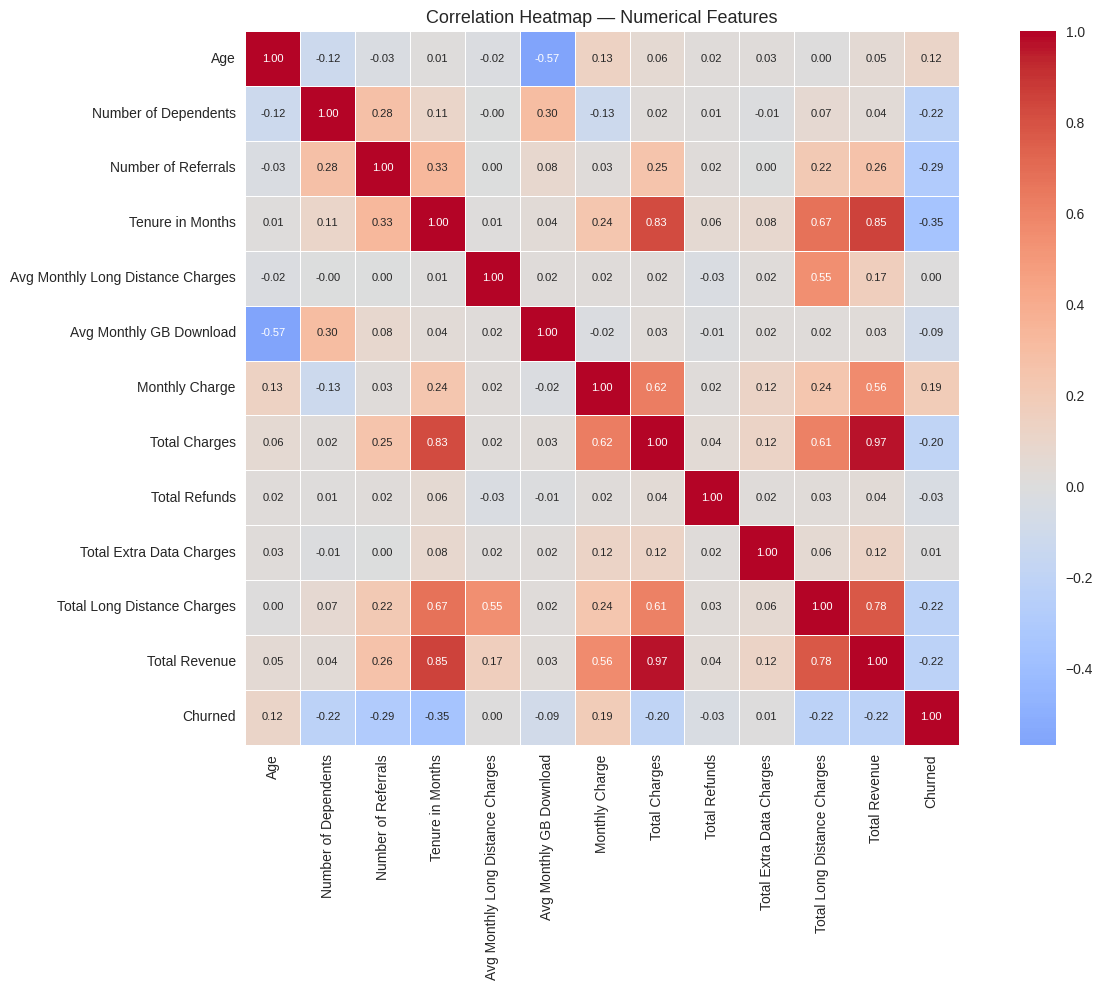

In [ ]:
# Correlation heatmap for numerical features
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
# Remove latitude, longitude, zip code
numerical_cols = [c for c in numerical_cols if c not in ['Latitude', 'Longitude', 'Zip Code']]

plt.figure(figsize=(14, 10))
corr_matrix = df[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, annot_kws={'size': 8})
plt.title('Correlation Heatmap — Numerical Features', fontsize=13)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary of Key Findings

This exploratory analysis reveals five
critical patterns that will guide our
modeling approach in Notebooks 2 and 3.

---

### Finding 1 — Class Imbalance Exists
26.5% of customers churned vs 73.5%
who stayed. We must handle this during
modeling to avoid the Accuracy Trap.

**Action:** Apply SMOTE in Notebook 2

---

### Finding 2 — Contract Type Drives Churn
Month-to-Month customers churn at
nearly 16x the rate of Two Year
contract customers.

**Action:** Contract type will be our
most important modeling feature —
confirmed by feature importance
score of 0.384

---

### Finding 3 — Referrals Signal Loyalty
More referrals = dramatically lower
churn risk. Customers who refer others
are publicly invested in the brand.

**Action:** Number of referrals becomes
second strongest predictor (0.108)

---

### Finding 4 — Early Tenure is Critical
Churn risk is highest in the first
12 months and drops consistently
as tenure increases.

**Action:** Monthly Spend Ratio
(charge / tenure) engineered in
Notebook 2 to capture this risk —
third strongest predictor (0.073)

---

### Finding 5 — Higher Charges = Higher Risk
Churned customers pay more monthly
on average than customers who stayed.

**Action:** Monthly Charge and
Monthly Spend Ratio both included
as key features

---

## What's Next

These findings directly inform our
feature engineering and modeling
decisions in Notebooks 2 and 3.

Every insight discovered here —
contract type, referrals, tenure,
monthly charge — is validated and
confirmed by our final Gradient
Boosting model's feature importance
scores.

This is the power of thorough
exploratory data analysis:

**The patterns we find here
tell us exactly where to look
in the model and the model
confirms what the data showed
us from the beginning.**

---

**Next:** Continue to `2_preprocessing.ipynb` to clean and prepare the data for modeling
